In [1]:
import sys
import pandas as pd
import numpy as np
import sklearn

print(sys.version)

3.12.14 (main, Sep  2 2026, 23:27:36) [GCC 15.3.0]


In [2]:
import pandas as pd
import numpy as np
import sklearn

print(pd.__version__)
print(np.__version__)
print(sklearn.__version__)

2.3.3
1.26.4
1.7.2


In [3]:
import boto3

s3 = boto3.client("s3")

response = s3.list_objects_v2(
    Bucket="bucket-name",
    Prefix="logisticsSQLGrafana"
)

for i in response.get("Contents", []):
    print(i["Key"])

logisticsSQLGrafana/DATABASE_SCHEMA.txt
logisticsSQLGrafana/customers.csv
logisticsSQLGrafana/delivery_events.csv
logisticsSQLGrafana/driver_monthly_metrics.csv
logisticsSQLGrafana/drivers.csv
logisticsSQLGrafana/facilities.csv
logisticsSQLGrafana/fuel_purchases.csv
logisticsSQLGrafana/loads.csv
logisticsSQLGrafana/maintenance_records.csv
logisticsSQLGrafana/routes.csv
logisticsSQLGrafana/safety_incidents.csv
logisticsSQLGrafana/trailers.csv
logisticsSQLGrafana/trips.csv
logisticsSQLGrafana/truck_utilization_metrics.csv
logisticsSQLGrafana/trucks.csv


In [5]:
response = s3.get_object(
    Bucket="bucket-name",
    Key="ML/delivery_delay_dataset.csv"
)

df = pd.read_csv(response["Body"])

print(f"length: {len(df)}")

length: 85410


## Data Inspection

In [6]:
df.head()

,trip_id,load_id,delayed,scheduled_datetime,dispatch_date,customer_id,load_type,weight_lbs,pieces,booking_type,...,years_experience,cdl_class,truck_id,truck_brand,model_year,fuel_type,truck_age,dispatch_day_of_week,dispatch_month,dispatch_year
0,TRIP00000001,LOAD00000001,0,2022-01-02 23:10:00,2022-01-01,CUST00183,Dry Van,19178,13,Spot,...,11.0,A,TRK00035,International,2015.0,Diesel,7.0,6,1,2022
1,TRIP00000002,LOAD00000002,1,2022-01-02 02:13:00,2022-01-01,CUST00076,Dry Van,27761,22,Dedicated,...,3.0,A,TRK00108,Volvo,2015.0,Diesel,7.0,6,1,2022
2,TRIP00000003,LOAD00000003,0,2022-01-03 04:28:00,2022-01-01,CUST00027,Refrigerated,35594,16,Spot,...,20.0,A,TRK00031,Kenworth,2018.0,Diesel,4.0,6,1,2022
3,TRIP00000004,LOAD00000004,1,2022-01-02 06:38:00,2022-01-01,CUST00088,Refrigerated,33274,10,Spot,...,21.0,A,TRK00105,Volvo,2015.0,Diesel,7.0,6,1,2022
4,TRIP00000005,LOAD00000005,0,2022-01-02 22:51:00,2022-01-01,CUST00185,Dry Van,40257,10,Spot,...,24.0,A,TRK00076,Kenworth,2015.0,Diesel,7.0,6,1,2022


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85410 entries, 0 to 85409
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   trip_id                 85410 non-null  object 
 1   load_id                 85410 non-null  object 
 2   delayed                 85410 non-null  int64  
 3   scheduled_datetime      85410 non-null  object 
 4   dispatch_date           85410 non-null  object 
 5   customer_id             85410 non-null  object 
 6   load_type               85410 non-null  object 
 7   weight_lbs              85410 non-null  int64  
 8   pieces                  85410 non-null  int64  
 9   booking_type            85410 non-null  object 
 10  route_id                85410 non-null  object 
 11  origin_state            85410 non-null  object 
 12  destination_state       85410 non-null  object 
 13  typical_distance_miles  85410 non-null  int64  
 14  transit_days            85410 non-null

In [8]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
trip_id,85410,85410,TRIP00085410,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
load_id,85410,85410,LOAD00085410,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
delayed,85410.0,NaN,NaN,NaN,0.553893,0.49709,0.0,0.0,1.0,1.0,1.0
scheduled_datetime,85410,83060,2024-05-30 13:52:00,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dispatch_date,85410,1096,2022-05-18,108,NaN,NaN,NaN,NaN,NaN,NaN,NaN
customer_id,85410,200,CUST00181,497,NaN,NaN,NaN,NaN,NaN,NaN,NaN
load_type,85410,2,Refrigerated,42946,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight_lbs,85410.0,NaN,NaN,NaN,27477.495305,10095.421857,10000.0,18724.0,27482.0,36190.0,45000.0
pieces,85410.0,NaN,NaN,NaN,14.47053,8.070077,1.0,7.0,14.0,21.0,28.0
booking_type,85410,3,Dedicated,42337,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df["delayed"].value_counts()

delayed
1    47308
0    38102
Name: count, dtype: int64

In [10]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing[missing > 0]

cdl_class           1714
years_experience    1714
truck_brand         1672
model_year          1672
fuel_type           1672
truck_age           1672
dtype: int64

In [11]:
"""import matplotlib.pyplot as plt

df["delayed"].value_counts().sort_index().plot(
    kind="bar",
    title="Delivery Delay Distribution"
)

plt.show()"""

'import matplotlib.pyplot as plt\n\ndf["delayed"].value_counts().sort_index().plot(\n    kind="bar",\n    title="Delivery Delay Distribution"\n)\n\nplt.show()'

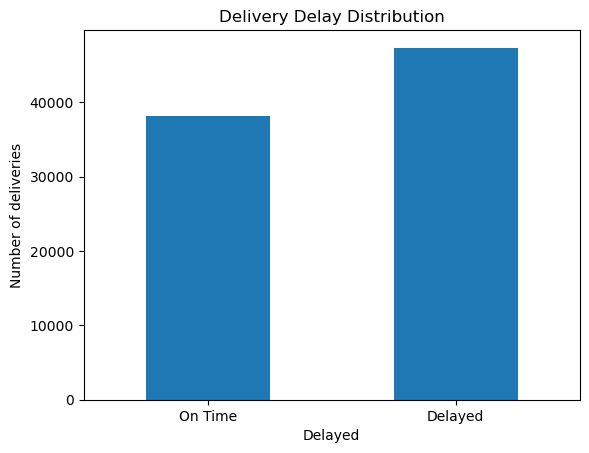

In [12]:
# check distribution of on-time and delayed orders

import matplotlib.pyplot as plt

df["delayed"].value_counts().sort_index().plot(
    kind="bar",
    title="Delivery Delay Distribution"
)

plt.xlabel("Delayed")
plt.ylabel("Number of deliveries")
plt.xticks([0, 1], ["On Time", "Delayed"], rotation=0)
plt.show()

In [13]:
df.columns.tolist()

['trip_id',
 'load_id',
 'delayed',
 'scheduled_datetime',
 'dispatch_date',
 'customer_id',
 'load_type',
 'weight_lbs',
 'pieces',
 'booking_type',
 'route_id',
 'origin_state',
 'destination_state',
 'typical_distance_miles',
 'transit_days',
 'driver_id',
 'years_experience',
 'cdl_class',
 'truck_id',
 'truck_brand',
 'model_year',
 'fuel_type',
 'truck_age',
 'dispatch_day_of_week',
 'dispatch_month',
 'dispatch_year']

In [14]:
# remove id columns becuase they dont provide any real information

remove = [
    'trip_id',
    'load_id',
    'customer_id',
    'route_id',
    'driver_id',
    'truck_id'
]

df_model = df.drop(columns=remove)

In [15]:
df_model.columns.tolist()

['delayed',
 'scheduled_datetime',
 'dispatch_date',
 'load_type',
 'weight_lbs',
 'pieces',
 'booking_type',
 'origin_state',
 'destination_state',
 'typical_distance_miles',
 'transit_days',
 'years_experience',
 'cdl_class',
 'truck_brand',
 'model_year',
 'fuel_type',
 'truck_age',
 'dispatch_day_of_week',
 'dispatch_month',
 'dispatch_year']

In [16]:
print(df.shape)
df_model.shape

(85410, 26)


(85410, 20)

In [17]:
#df_model.head(5)

In [18]:
df_model.shape

(85410, 20)

In [19]:
# converting datatype of columns (int -> datetime) having date and time features

df_model['scheduled_datetime'] = pd.to_datetime(df['scheduled_datetime'])

df_model['dispatch_date'] = pd.to_datetime(df['dispatch_date'])

In [20]:
# extracting features from just type-converted fields

df_model['scheduled_hour'] = df_model['scheduled_datetime'].dt.hour

df_model['scheduled_day_of_week'] = df_model['scheduled_datetime'].dt.dayofweek

df_model['scheduled_day_of_month'] = df_model['scheduled_datetime'].dt.day

In [21]:
df_model.head()

,delayed,scheduled_datetime,dispatch_date,load_type,weight_lbs,pieces,booking_type,origin_state,destination_state,typical_distance_miles,...,truck_brand,model_year,fuel_type,truck_age,dispatch_day_of_week,dispatch_month,dispatch_year,scheduled_hour,scheduled_day_of_week,scheduled_day_of_month
0,0,2022-01-02 23:10:00,2022-01-01,Dry Van,19178,13,Spot,TX,MI,1271,...,International,2015.0,Diesel,7.0,6,1,2022,23,6,2
1,1,2022-01-02 02:13:00,2022-01-01,Dry Van,27761,22,Dedicated,MO,IN,519,...,Volvo,2015.0,Diesel,7.0,6,1,2022,2,6,2
2,0,2022-01-03 04:28:00,2022-01-01,Refrigerated,35594,16,Spot,OH,OR,2332,...,Kenworth,2018.0,Diesel,4.0,6,1,2022,4,0,3
3,1,2022-01-02 06:38:00,2022-01-01,Refrigerated,33274,10,Spot,AZ,CO,673,...,Volvo,2015.0,Diesel,7.0,6,1,2022,6,6,2
4,0,2022-01-02 22:51:00,2022-01-01,Dry Van,40257,10,Spot,TX,WA,2172,...,Kenworth,2015.0,Diesel,7.0,6,1,2022,22,6,2


In [22]:
df_model.drop(columns=['scheduled_datetime','dispatch_date'])

,delayed,load_type,weight_lbs,pieces,booking_type,origin_state,destination_state,typical_distance_miles,transit_days,years_experience,...,truck_brand,model_year,fuel_type,truck_age,dispatch_day_of_week,dispatch_month,dispatch_year,scheduled_hour,scheduled_day_of_week,scheduled_day_of_month
0,0,Dry Van,19178,13,Spot,TX,MI,1271,2,11.0,...,International,2015.0,Diesel,7.0,6,1,2022,23,6,2
1,1,Dry Van,27761,22,Dedicated,MO,IN,519,1,3.0,...,Volvo,2015.0,Diesel,7.0,6,1,2022,2,6,2
2,0,Refrigerated,35594,16,Spot,OH,OR,2332,4,20.0,...,Kenworth,2018.0,Diesel,4.0,6,1,2022,4,0,3
3,1,Refrigerated,33274,10,Spot,AZ,CO,673,1,21.0,...,Volvo,2015.0,Diesel,7.0,6,1,2022,6,6,2
4,0,Dry Van,40257,10,Spot,TX,WA,2172,3,24.0,...,Kenworth,2015.0,Diesel,7.0,6,1,2022,22,6,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85405,1,Refrigerated,20353,20,Dedicated,MN,GA,1044,1,12.0,...,International,2016.0,Diesel,8.0,2,12,2024,0,2,1
85406,0,Dry Van,23061,11,Contract,TX,CO,762,1,17.0,...,Volvo,2015.0,Diesel,9.0,2,12,2024,7,2,1
85407,1,Refrigerated,12570,15,Contract,MO,OR,1718,2,15.0,...,Mack,2016.0,Diesel,8.0,2,12,2024,17,2,1
85408,1,Refrigerated,34121,7,Dedicated,PA,WA,2729,4,15.0,...,Mack,2016.0,Diesel,8.0,2,12,2024,16,3,2


In [23]:
x = df_model.drop(columns=['delayed'])
y = df_model["delayed"]

In [24]:
print("Faetures: ", x.shape)
print("Target: ", y.shape)

Faetures:  (85410, 22)
Target:  (85410,)


In [25]:
df['dispatch_date'] = pd.to_datetime(df['dispatch_date'])

print("Min: ", df["dispatch_date"].min())
print("Max: ", df["dispatch_date"].max())

Min:  2022-01-01 00:00:00
Max:  2024-12-31 00:00:00


In [26]:
df_model.shape

(85410, 23)

In [27]:
#save final dataframe df_model as csv file in s3

"""bucket = "<bucket-name>"
output_key = "ML/delivery_delay_features.csv"

df_model.to_csv("/tmp/delivery_delay_features.csv", index=False)

s3.upload_file(
    "/tmp/delivery_delay_features.csv",
    bucket,
    output_key
)"""

'bucket = "<bucket-name>"\noutput_key = "ML/delivery_delay_features.csv"\n\ndf_model.to_csv("/tmp/delivery_delay_features.csv", index=False)\n\ns3.upload_file(\n    "/tmp/delivery_delay_features.csv",\n    bucket,\n    output_key\n)'

## revisiting notebook 1 after model after training on model in notebook 2
### results of model training are not viable hence re-checking the feature on df_model

In [28]:
# route pair feature

df_model['route_pair'] = ( df_model["origin_state"].astype(str) + "_" + df_model["destination_state"].astype(str) )

In [29]:
#create distance intensity

df_model["distance_per_transit_day"] = ( df_model["typical_distance_miles"]/df_model["transit_days"].replace(0,np.nan) )

df_model["distance_per_transit_day"] = ( df_model["distance_per_transit_day"].replace([np.inf, -np.inf], np.nan) )

In [31]:
#weekend indicators

df_model["is_dispatch_weekend"] = (df_model["dispatch_day_of_week"]>=5).astype(int)

df_model["is_scheduled_weekend"] = (df_model["scheduled_day_of_week"]>=5).astype(int)

In [32]:
# month/season indicator

df_model["is_peak_period"] = (df_model["dispatch_month"].isin([6,7,8,11,12])).astype(int)

In [33]:
# creating truck age x distance relationship

df_model["truck_age_distance"] = (df_model["truck_age"]*df_model["typical_distance_miles"])

df_model["experience_distance"] = (df_model["years_experience"]*df_model["typical_distance_miles"])

In [34]:
# schedules vs dispatch timings

df_model["dispatch_lead_days"] = (df_model["scheduled_datetime"].dt.normalize() - df_model["dispatch_date"].dt.normalize()).dt.days

df_model["dispatch_lead_days"].describe()

count    85410.000000
mean         1.093631
std          0.702953
min          0.000000
25%          1.000000
50%          1.000000
75%          2.000000
max          3.000000
Name: dispatch_lead_days, dtype: float64

In [35]:
# check target relationship

new_features = [
    "distance_per_transit_day",
    "is_dispatch_weekend",
    "is_scheduled_weekend",
    "is_peak_period",
    "truck_age_distance",
    "experience_distance",
    "dispatch_lead_days"
]

#print(df_model[new_features + ["delayed"]].groupby("delayed").mean(numeric_only=True) )
df_model[new_features + ["delayed"]].groupby("delayed").mean(numeric_only=True)

,distance_per_transit_day,is_dispatch_weekend,is_scheduled_weekend,is_peak_period,truck_age_distance,experience_distance,dispatch_lead_days
delayed,,,,,,,
0,650.471139,0.283660,0.286494,0.417065,9856.890805,19112.372848,1.094641
1,651.414234,0.283884,0.286252,0.419739,9864.122241,19072.039244,1.092817


In [36]:
print(df_model[new_features + ["delayed"]].corr(numeric_only=True)["delayed"].sort_values() )

experience_distance        -0.001293
dispatch_lead_days         -0.001289
is_scheduled_weekend       -0.000266
is_dispatch_weekend         0.000248
truck_age_distance          0.000586
distance_per_transit_day    0.002626
is_peak_period              0.002694
delayed                     1.000000
Name: delayed, dtype: float64


In [37]:
# above result show that the features engineered dont help predicting the target variable becuase there is no correlation among the elements

In [38]:
# checking categorical variable analysis

pd.crosstab(df_model["origin_state"], df_model["delayed"], normalize="index").sort_values(1, ascending=False).head(10)

delayed,0,1
origin_state,,
GA,0.428669,0.571331
TN,0.428956,0.571044
WA,0.434312,0.565688
CO,0.439203,0.560797
MN,0.439601,0.560399
PA,0.440567,0.559433
OH,0.443832,0.556168
OR,0.445321,0.554679
NC,0.446091,0.553909


In [39]:
pd.crosstab(df_model["load_type"], df_model["delayed"], normalize="index")

delayed,0,1
load_type,,
Dry Van,0.445507,0.554493
Refrigerated,0.446701,0.553299


In [40]:
pd.crosstab(df_model["booking_type"], df_model["delayed"], normalize="index")

delayed,0,1
booking_type,,
Contract,0.445811,0.554189
Dedicated,0.445166,0.554834
Spot,0.448253,0.551747


In [41]:
pd.crosstab(df_model["truck_brand"], df_model["delayed"], normalize="index")

delayed,0,1
truck_brand,,
Freightliner,0.446193,0.553807
International,0.442848,0.557152
Kenworth,0.443569,0.556431
Mack,0.443183,0.556817
Peterbilt,0.446629,0.553371
Volvo,0.451562,0.548438


In [44]:
print(df.columns.tolist())

['trip_id', 'load_id', 'delayed', 'scheduled_datetime', 'dispatch_date', 'customer_id', 'load_type', 'weight_lbs', 'pieces', 'booking_type', 'route_id', 'origin_state', 'destination_state', 'typical_distance_miles', 'transit_days', 'driver_id', 'years_experience', 'cdl_class', 'truck_id', 'truck_brand', 'model_year', 'fuel_type', 'truck_age', 'dispatch_day_of_week', 'dispatch_month', 'dispatch_year']


In [45]:
print(df_model.columns.tolist())

['delayed', 'scheduled_datetime', 'dispatch_date', 'load_type', 'weight_lbs', 'pieces', 'booking_type', 'origin_state', 'destination_state', 'typical_distance_miles', 'transit_days', 'years_experience', 'cdl_class', 'truck_brand', 'model_year', 'fuel_type', 'truck_age', 'dispatch_day_of_week', 'dispatch_month', 'dispatch_year', 'scheduled_hour', 'scheduled_day_of_week', 'scheduled_day_of_month', 'route_pair', 'distance_per_transit_day', 'is_dispatch_weekend', 'is_scheduled_weekend', 'is_peak_period', 'truck_age_distance', 'experience_distance', 'dispatch_lead_days']


In [46]:
print(df["route_id"].nunique())
print(df["driver_id"].nunique())
print(df["truck_id"].nunique())

58
125
93


In [47]:
print(df.groupby("route_id")["delayed"].agg(["count","mean"]).describe() )

             count       mean
count    58.000000  58.000000
mean   1472.586207   0.553905
std      38.057682   0.013544
min    1386.000000   0.520027
25%    1447.750000   0.546293
50%    1472.000000   0.553899
75%    1491.000000   0.564421
max    1628.000000   0.576005


# Notebook 01 — Data Ingestion, Validation, EDA & Feature Engineering

## Overview

This notebook prepares the logistics dataset for downstream analytics and machine learning. Data was accessed from Amazon S3 within the AWS environment, loaded into Pandas, validated for quality and consistency, explored through exploratory data analysis (EDA), and transformed into a modelling-ready dataset.

## Data Preparation

The dataset contains logistics, shipment, route, driver, vehicle and scheduling information covering deliveries from 2022 to 2024. Key variables include:

- Shipment and route identifiers
- Origin and destination states
- Load and booking characteristics
- Distance and expected transit duration
- Driver experience and CDL class
- Truck characteristics
- Dispatch and scheduled-date information
- Delivery delay indicator (`delayed`)

Data validation confirmed the expected dataset structure and identified missing values in several driver and vehicle attributes. Missing numerical values were retained for appropriate imputation during model preprocessing, while categorical missing values were handled as an explicit category.

## Exploratory Data Analysis — Key Findings

The target variable `delayed` showed an approximately 55% delayed / 45% non-delayed distribution.

Initial analysis found very limited separation between delayed and non-delayed deliveries. Numerical variables such as:

- Weight
- Number of pieces
- Distance
- Transit duration
- Driver experience
- Truck age

showed almost identical averages across the two target classes.

Categorical analysis also showed very similar delay proportions across origin states, load types, booking types and truck brands.

Route-level analysis identified 58 unique routes, with historical delay rates ranging only from approximately 52% to 58%, indicating limited variation in route-level delay behaviour.

## Feature Engineering

Additional features were created to investigate whether operational relationships could provide predictive signal, including:

- Origin-to-destination route pairs
- Distance per transit day
- Dispatch and scheduled weekend indicators
- Peak-period indicator
- Truck age × distance interaction
- Driver experience × distance interaction
- Dispatch lead time

These features were evaluated against the target to determine whether they provided meaningful separation between delayed and non-delayed deliveries.

## Key EDA Insight

The engineered features continued to show extremely weak relationships with `delayed`. Correlations with the target remained close to zero, while group-level comparisons showed minimal differences between delayed and non-delayed observations.

This indicated that the available dataset contained limited observable information capable of explaining the `delayed` outcome.

## Output

Following validation, EDA and feature engineering, the resulting modelling dataset was saved as `df_model` and used as the input for Notebook 02.

The findings from this notebook were carried forward into the machine-learning feasibility assessment rather than assuming that the target was inherently predictable.